In [1]:
import sys 
sys.path.append("../")
from LCSS.LCSS_core import * 
from state import Hamiltonian, StateMachine, generate_Sright_all

In [2]:
from copy import copy

def random_ising_model(n):
    init = ["_"] * n
    paulis = []
    for i in range(n-1):
        p = copy(init)
        for idx in range(i,i+2):
            p[idx]  = "Z"
        paulis.append("".join(p))
    
    for i in range(n-2):
        p = copy(init)
        p[i]  = "X"
        paulis.append("".join(p))
        
    coeffs = np.random.randint(0,2,len(paulis)) *  2 -1
        
    return coeffs,paulis

In [3]:
x = np.array([1,5,10,15,20])

In [4]:
from tqdm.notebook import tqdm
import scipy
n = 12
from qiskit.quantum_info import Operator,SparsePauliOp 
def fix(s):
    out = ""
    for i in s:
        if(i=="_"):
            out+="I"
        else:
            out+=i 
    return out 


l_data = []
lz_data = []
for i in range(10):
    coeffs, paulis = random_ising_model(n)
    H = Pauli_Hamiltonian(coeffs, paulis)    
    _,groups,phases,_ = get_excited_states(H.convert_to_spare_hamiltonian(),np.max(x))
    HZ = Pauli_Hamiltonian(coeffs[:-(n-2)], paulis[:-(n-2)])
    _,groupsz,phasesz,_ = get_excited_states(HZ.convert_to_spare_hamiltonian(),np.max(x))
    
    l = [] 
    lz = []
    for _ in tqdm(x):
        circs = get_circs(groups,phases,H)[:_]
        l.append(H.LCSS_opt(circs)[0])
        
        circsz = get_circs(groupsz,phasesz,H)[:_]
        lz.append(H.LCSS_opt(circsz)[0])

    o = SparsePauliOp(data = [fix(p) for p in paulis],coeffs= coeffs).to_matrix(sparse=True)  
    g = scipy.sparse.linalg.eigsh(o,which='SA',k=1)[0][0] 
    l_data.append(abs((g- np.array(l))/g))
    lz_data.append(abs((g- np.array(lz))/g))



  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

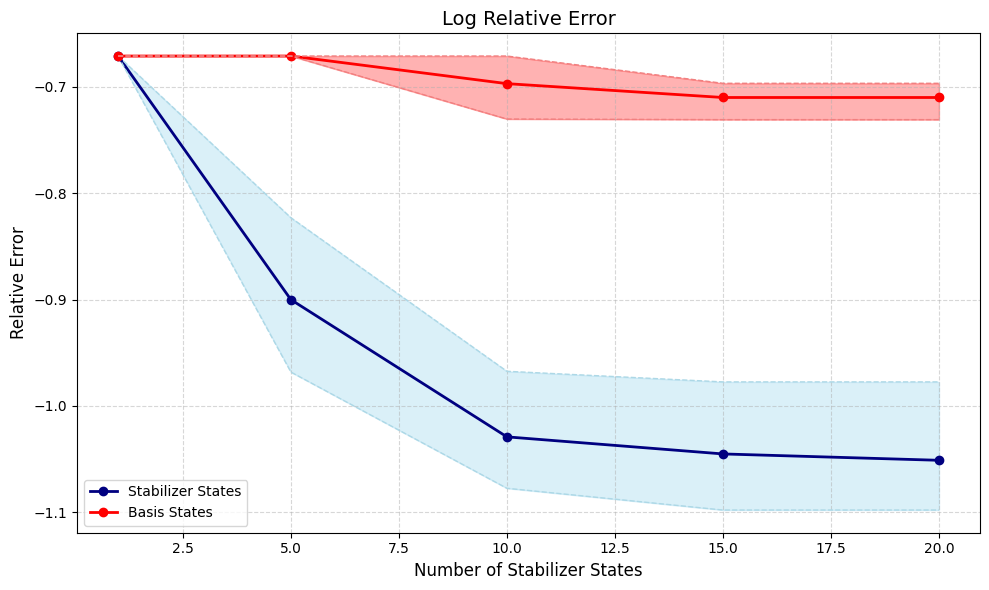

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming `x` and `l_data` are already defined

# Compute mean, min, and max
mean_log = np.log10(np.mean(l_data, axis=0))
min_log = np.log10(np.min(l_data, axis=0))
max_log = np.log10(np.max(l_data, axis=0))

mean_logz = np.log10(np.mean(lz_data, axis=0))
min_logz = np.log10(np.min(lz_data, axis=0))
max_logz = np.log10(np.max(lz_data, axis=0))

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, mean_log, '-o',label='Stabilizer States', color='navy', linewidth=2)
plt.fill_between(x, min_log, max_log, color='skyblue', alpha=0.3)
plt.plot(x, min_log, linestyle='--', color='lightblue', linewidth=1)
plt.plot(x, max_log, linestyle='--', color='lightblue', linewidth=1)

plt.plot(x, mean_logz, '-o',label='Basis States', color='red', linewidth=2)
plt.fill_between(x, min_logz, max_logz, color='red', alpha=0.3)
plt.plot(x, min_logz, linestyle='--', color='lightcoral', linewidth=1)
plt.plot(x, max_logz, linestyle='--', color='lightcoral', linewidth=1)


# Style and labels
plt.title('Log Relative Error', fontsize=14)
plt.xlabel('Number of Stabilizer States', fontsize=12)
plt.ylabel('Relative Error', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

In [6]:
from tqdm.notebook import tqdm
from qiskit.quantum_info import Operator,SparsePauliOp 

total_error = []
total_errorz = []

for _ in range(5):
    error = []
    errorz = []
    for n in tqdm(range(6,21)):
        coeffs, paulis = random_ising_model(n)
        H = Pauli_Hamiltonian(coeffs, paulis)    
        _,groups,phases,_ = get_excited_states(H.convert_to_spare_hamiltonian(),np.max(x))
        HZ = Pauli_Hamiltonian(coeffs[:-(n-2)], paulis[:-(n-2)])
        _,groupsz,phasesz,_ = get_excited_states(HZ.convert_to_spare_hamiltonian(),np.max(x))
        
        circs = get_circs(groups,phases,H)
        circsz = get_circs(groupsz,phasesz,H)
        
        energy = (H.LCSS_opt(circs)[0])
        energyz = (H.LCSS_opt(circsz)[0])

        
        o = SparsePauliOp(data = [fix(p) for p in paulis],coeffs= coeffs).to_matrix(sparse=True)  
        g = scipy.sparse.linalg.eigsh(o,which='SA',k=1)[0][0] 
        error.append(abs((g- energy)/g))
        errorz.append(abs((g- energyz)/g))
        
    total_error.append(error)
    total_errorz.append(errorz)

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

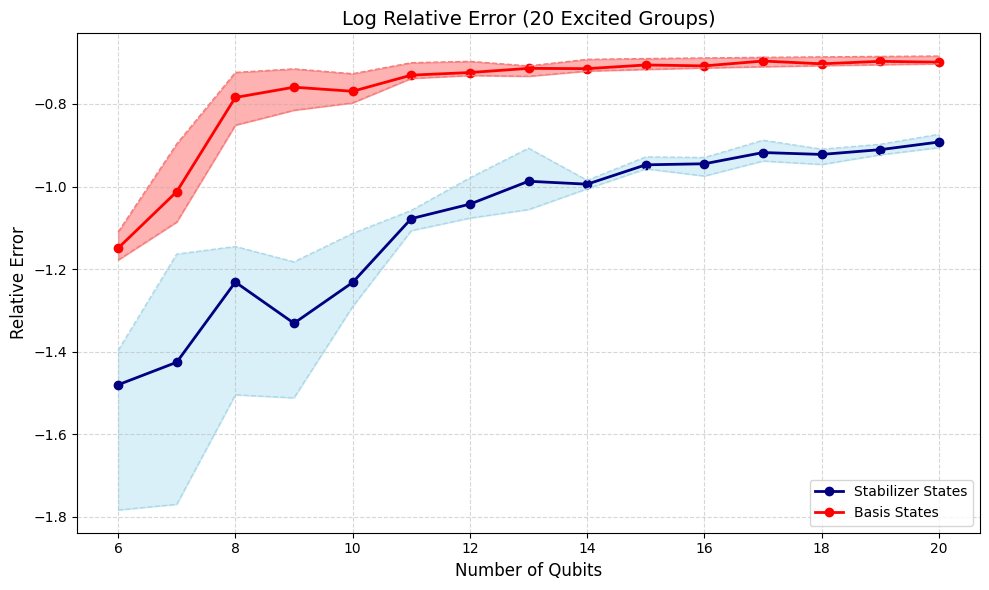

In [7]:
import matplotlib.pyplot as plt
import numpy as np

x=range(6,21)
# Compute mean, min, and max
mean_log = np.log10(np.mean(total_error,axis=0))
min_log = np.log10(np.min(total_error,axis=0))
max_log = np.log10(np.max(total_error,axis=0))

mean_logz = np.log10(np.mean(total_errorz,axis=0))
min_logz = np.log10(np.min(total_errorz,axis=0))
max_logz = np.log10(np.max(total_errorz,axis=0))


# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, mean_log, '-o',label='Stabilizer States', color='navy', linewidth=2)
plt.fill_between(x, min_log, max_log, color='skyblue', alpha=0.3)
plt.plot(x, min_log, linestyle='--', color='lightblue', linewidth=1)
plt.plot(x, max_log, linestyle='--', color='lightblue', linewidth=1)

plt.plot(x, mean_logz, '-o',label='Basis States', color='red', linewidth=2)
plt.fill_between(x, min_logz, max_logz, color='red', alpha=0.3)
plt.plot(x, min_logz, linestyle='--', color='lightcoral', linewidth=1)
plt.plot(x, max_logz, linestyle='--', color='lightcoral', linewidth=1)


# Style and labels
plt.title('Log Relative Error (20 Excited Groups)', fontsize=14)
plt.xlabel('Number of Qubits', fontsize=12)
plt.ylabel('Relative Error', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()